## 1. Imports

In [12]:
import numpy as np
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
import pandas as pd
from statsmodels.graphics.gofplots import qqplot
import scipy.stats as stats

## 2. Configuración

In [13]:
FREQ     = 144           # Muestras por día (cada 10 min → 6×24)
PRED_LEN = FREQ * 7      # Predecir 1 semana = 1.008 pasos

# ── CLAVE: ventana de entrada muy corta ──────────────────────────────────────

SEQ_LEN  = FREQ * 1    # 1 día #cuanto tiene en cuenta el modelo para predecir 
#decir en el documento que no pudimos hacerlo mas grande ya que era imposible entrenarlo con el hardware del que disponiamos

EPOCHS     = 30
BATCH      = 32          # Batches más grandes → gradientes más estables, mismo tiempo
LR         = 1e-3
MODEL_PATH = "transformer_cpu.pth"
DEVICE     = "cpu"       

# ── Arquitectura ─────────────────────────────────────────────────────────────
D_MODEL         = 32
NHEAD           = 4      # D_MODEL debe ser divisible por NHEAD
ENC_LAYERS      = 2
DIM_FEEDFORWARD = 64
DROPOUT         = 0.1

print(f"SEQ_LEN={SEQ_LEN} | PRED_LEN={PRED_LEN} | BATCH={BATCH} | DEVICE={DEVICE}")

SEQ_LEN=144 | PRED_LEN=1008 | BATCH=32 | DEVICE=cpu


## 3. Datos y normalización

In [14]:
data = pd.read_csv("../powerconsumption.csv")
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime").set_index("Datetime")

series = data["PowerConsumption_Zone1"].dropna().values.astype("float32")

# Normalización Min-Max — fit solo sobre train
split = int(len(series) * 0.8)
s_min = series[:split].min()
s_max = series[:split].max()
series_norm = (series - s_min) / (s_max - s_min)

train_data = series_norm[:split]
test_data  = series_norm[split:]

print(f"Train: {len(train_data):,} | Test: {len(test_data):,} muestras")

Train: 41,932 | Test: 10,484 muestras


## 4. Dataset

In [15]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data     = data
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(-1),  # (seq_len, 1)
            torch.tensor(y, dtype=torch.float32).unsqueeze(-1),  # (pred_len, 1)
        )

train_ds = TimeSeriesDataset(train_data, SEQ_LEN, PRED_LEN)
test_ds  = TimeSeriesDataset(test_data,  SEQ_LEN, PRED_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f"Train batches: {len(train_dl)} | Test batches: {len(test_dl)}")

Train batches: 1275 | Test batches: 292


## 5. Modelo — Transformer Encoder-Only

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TransformerEncoderForecaster(nn.Module):
    """
    Transformer ENCODER-ONLY para forecasting de longitud fija.

    Flujo:
      (B, seq_len, 1)
        → proyección lineal → (B, seq_len, d_model)
        → positional encoding
        → N capas de TransformerEncoderLayer  ← solo atención self (sin decoder)
        → flatten del token [CLS] / promedio
        → cabeza lineal → (B, pred_len)
    """

    def __init__(self, seq_len, pred_len, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=ENC_LAYERS, dim_feedforward=DIM_FEEDFORWARD,
                 dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=seq_len, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Cabeza de predicción: toma el promedio de todos los tokens
        # y proyecta directamente a pred_len valores
        self.head = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, pred_len),
        )

    def forward(self, x):           # x: (B, seq_len, 1)
        x = self.pos_enc(self.input_proj(x))   # (B, seq_len, d_model)
        x = self.encoder(x)                    # (B, seq_len, d_model)
        x = x.mean(dim=1)                      # (B, d_model)  — pooling temporal
        return self.head(x).unsqueeze(-1)       # (B, pred_len, 1)


model = TransformerEncoderForecaster(seq_len=SEQ_LEN, pred_len=PRED_LEN)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total:,}")

Parámetros entrenables: 84,784


## 6. Entrenamiento

In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        pred = model(x)                   # (B, pred_len, 1)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total = 0.0
    for x, y in loader:
        total += criterion(model(x), y).item()
    return total / len(loader)


if os.path.exists(MODEL_PATH):
    print(f"Cargando pesos desde '{MODEL_PATH}'...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
    criterion = nn.MSELoss()

    best_val = float("inf")
    history  = {"train": [], "val": []}

    for epoch in range(1, EPOCHS + 1):
        tr  = train_epoch(model, train_dl, optimizer, criterion)
        val = eval_epoch(model, test_dl, criterion)
        scheduler.step()
        history["train"].append(tr)
        history["val"].append(val)

        if val < best_val:
            best_val = val
            torch.save(model.state_dict(), MODEL_PATH)

        if epoch % 2 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {tr:.6f} | Val: {val:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    print(f"\nMejor Val MSE: {best_val:.6f} → guardado en '{MODEL_PATH}'")

    plt.figure(figsize=(8, 3))
    plt.plot(history["train"], label="Train")
    plt.plot(history["val"],   label="Val")
    plt.xlabel("Epoch"); plt.ylabel("MSE")
    plt.title("Curva de pérdida"); plt.legend()
    plt.tight_layout(); plt.savefig("loss_curve.png", dpi=150); plt.show()

Cargando pesos desde 'transformer_cpu.pth'...


## 7. Evaluación visual y métricas

MAE=1926.6 W | RMSE=2481.8 W | MAPE=6.25%


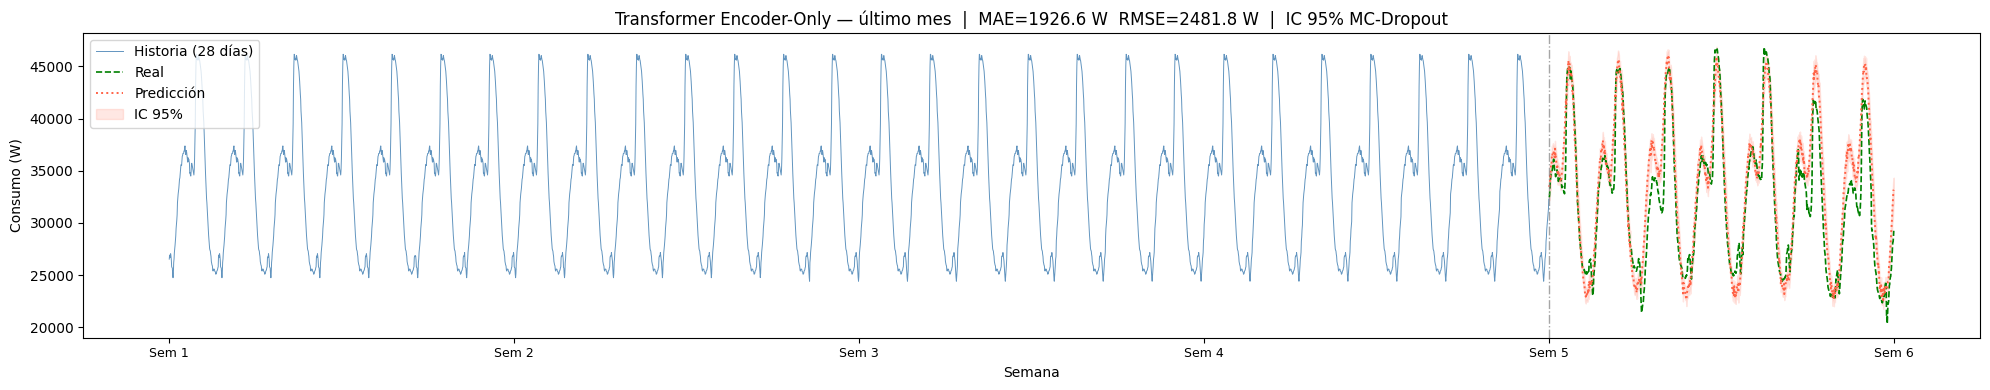

In [20]:
# ── MC Dropout: inferencia estocástica para intervalo de confianza ────────────
N_SAMPLES = 100   # cuantas pasadas forward con dropout activo

def enable_dropout(m):
    """Reactiva dropout en eval mode."""
    if isinstance(m, torch.nn.Dropout):
        m.train()

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
model.apply(enable_dropout)   # dropout ON, resto en eval

# ── Acumular ~1 mes de historia desde el dataset ──────────────────────────────
STEPS_PER_DAY  = 144
STEPS_PER_WEEK = STEPS_PER_DAY * 7
MONTH_STEPS    = STEPS_PER_DAY * 28

denorm = lambda v: v * (s_max - s_min) + s_min

history_chunks = []
n_samples = min(MONTH_STEPS // SEQ_LEN + 2, len(test_ds))
for i in range(n_samples):
    xc, _ = test_ds[i]
    history_chunks.append(denorm(xc.squeeze().numpy()))

hist_full = np.concatenate(history_chunks)[-MONTH_STEPS:]

# ── Muestra de evaluación ─────────────────────────────────────────────────────
x_test, y_test = test_ds[n_samples - 1]

with torch.no_grad():
    preds = np.stack([
        model(x_test.unsqueeze(0)).squeeze().numpy()
        for _ in range(N_SAMPLES)
    ])  # (N_SAMPLES, PRED_LEN)

preds_denorm = denorm(preds)                        # (N_SAMPLES, PRED_LEN)
y_pred_raw   = preds_denorm.mean(axis=0)            # media
ci_low       = np.percentile(preds_denorm,  2.5, axis=0)   # IC 95%
ci_high      = np.percentile(preds_denorm, 97.5, axis=0)

y_true_raw = denorm(y_test.squeeze().numpy())

mae  = np.mean(np.abs(y_true_raw - y_pred_raw))
rmse = np.sqrt(np.mean((y_true_raw - y_pred_raw) ** 2))
mape = np.mean(np.abs((y_true_raw - y_pred_raw) / (y_true_raw + 1e-8))) * 100
print(f"MAE={mae:.1f} W | RMSE={rmse:.1f} W | MAPE={mape:.2f}%")

# ── Ejes temporales ───────────────────────────────────────────────────────────
actual_hist = len(hist_full)
t_hist = np.arange(0, actual_hist)
t_pred = np.arange(actual_hist, actual_hist + PRED_LEN)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 4))

ax.plot(t_hist, hist_full,  color="steelblue", label="Historia (28 días)", lw=0.7, alpha=0.85)
ax.plot(t_pred, y_true_raw, color="green",  linestyle="--", label="Real",       lw=1.2)
ax.plot(t_pred, y_pred_raw, color="tomato", linestyle=":",  label="Predicción", lw=1.4)

# Banda de confianza 95%
ax.fill_between(t_pred, ci_low, ci_high, color="tomato", alpha=0.15, label="IC 95%")

ax.axvline(actual_hist, color="gray", lw=1.0, alpha=0.7, linestyle="-.")

# Ticks cada semana
week_ticks = np.arange(0, actual_hist + PRED_LEN + 1, STEPS_PER_WEEK)
ax.set_xticks(week_ticks)
ax.set_xticklabels([f"Sem {i+1}" for i in range(len(week_ticks))], fontsize=9)

ax.set_xlabel("Semana"); ax.set_ylabel("Consumo (W)")
ax.set_title(f"Transformer Encoder-Only — último mes  |  MAE={mae:.1f} W  RMSE={rmse:.1f} W  |  IC 95% MC-Dropout")
ax.legend(loc="upper left"); plt.tight_layout()
plt.savefig("forecast_cpu.png", dpi=150); plt.show()

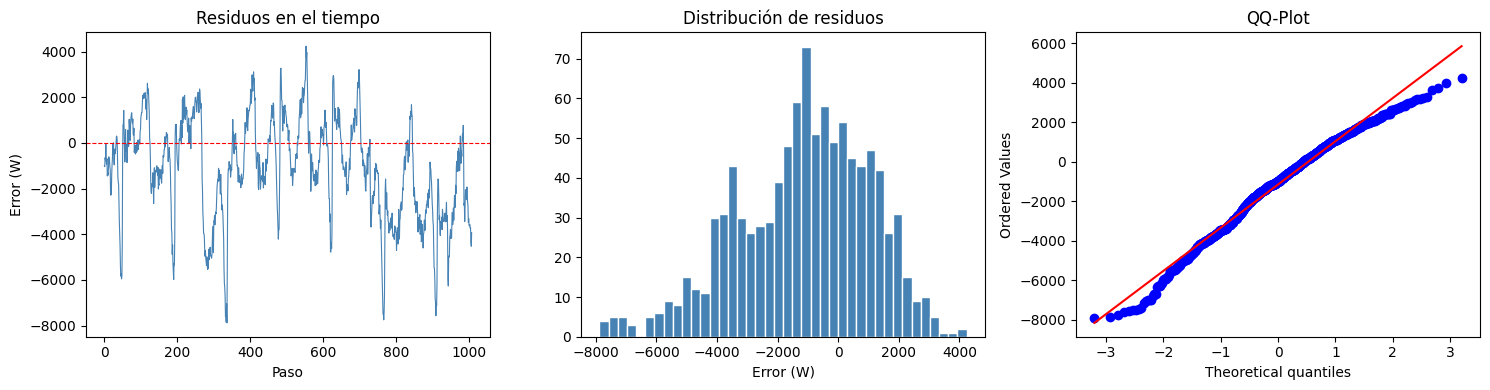

In [21]:

residuals = y_true_raw - y_pred_raw

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuos en el tiempo
axes[0].plot(residuals, color="steelblue", lw=0.8)
axes[0].axhline(0, color="red", lw=0.8, linestyle="--")
axes[0].set_title("Residuos en el tiempo")
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("Error (W)")

# 2. Histograma de residuos
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Error (W)")

# 3. QQ-plot manual
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot")

plt.tight_layout()
plt.savefig("diagnostics.png", dpi=150)
plt.show()